# GoML AI Engineer Case Study
## Part 1 — Student Placement Prediction

### Objective

The goal of this task is to predict whether a student will be placed based on the information available about the student.

The target variable is `placed`:

- `0` → Not placed
- `1` → Placed

The evaluation metric is the F1-score for the positive class (`placed = 1`).

Since the dataset is imbalanced, I will not rely only on accuracy. Instead, I will focus mainly on precision, recall, and F1-score for the placed class.

I will compare four different approaches:

1. Logistic Regression
2. Random Forest
3. LightGBM
4. XGBoost

Before training the models, I will also perform a data-quality and leakage check.

In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import warnings

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## 2. Loading the training data

I first load the training dataset and inspect its shape and first few rows.

At this stage I am not making any assumptions about the data. The purpose is simply to understand what has been provided.


In [21]:
DATA_PATH = "data/train.csv"

df = pd.read_csv(DATA_PATH,)

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (2500, 11)


,student_id,department,city_tier,cgpa,backlogs,internship_months,coding_score,projects,workshops,status_code,placed
0,S00802,CSE,2,7.00,1.0,5,56.6,5,4,NaN,1
1,S02107,CSE,3,8.06,1.0,4,29.9,1,3,1.0,1
2,S01945,CSE,3,7.92,0.0,0,52.4,2,2,0.0,0
3,S01956,MECH,2,7.49,1.0,1,37.3,1,1,0.0,0
4,S01828,CSE,2,8.80,NaN,0,82.2,2,3,1.0,1


## 3. Understanding the dataset

Before building a model, I want to understand what each column contains.

In particular, I want to identify:

- the target variable
- identifier columns
- numerical features
- categorical features
- columns that may contain leakage

In [22]:
print("Column names:\n")

for column in df.columns:
    print(f"- {column}")

Column names:

- student_id
- department
- city_tier
- cgpa
- backlogs
- internship_months
- coding_score
- projects
- workshops
- status_code
- placed


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   student_id         2500 non-null   str    
 1   department         2500 non-null   str    
 2   city_tier          2500 non-null   int64  
 3   cgpa               2382 non-null   float64
 4   backlogs           2332 non-null   float64
 5   internship_months  2500 non-null   int64  
 6   coding_score       1975 non-null   float64
 7   projects           2500 non-null   int64  
 8   workshops          2500 non-null   int64  
 9   status_code        2387 non-null   float64
 10  placed             2500 non-null   int64  
dtypes: float64(4), int64(5), str(2)
memory usage: 236.9 KB


In [24]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
city_tier,2500.0,1.930000,0.767682,1.0,1.0,2.00,3.0000,3.0
cgpa,2382.0,7.274551,0.853967,5.0,6.7,7.29,7.8575,10.0
backlogs,2332.0,0.743997,0.871437,0.0,0.0,1.00,1.0000,6.0
internship_months,2500.0,1.975200,2.137197,0.0,0.0,1.00,4.0000,6.0
coding_score,1975.0,54.278177,16.306036,5.2,43.4,54.30,65.2000,100.0
projects,2500.0,1.510800,1.290019,0.0,1.0,1.00,2.0000,10.0
workshops,2500.0,2.085600,1.416713,0.0,1.0,2.00,3.0000,4.0
status_code,2387.0,0.293255,0.455350,0.0,0.0,0.00,1.0000,1.0
placed,2500.0,0.280800,0.449480,0.0,0.0,0.00,1.0000,1.0


## Missing-value analysis

Some student records contain missing values.

I do not want to remove those rows because the dataset is relatively small, and removing students would unnecessarily reduce the amount of training data.

I will therefore impute the missing values during preprocessing.

For numerical features, I will use the median of the training data. The median is less sensitive to extreme values than the mean, which makes it a safer choice for features such as CGPA, coding score, and backlog counts.

For categorical features, I will use the most frequent category.

Importantly, the imputation values will be learned only from the training data through the preprocessing pipeline. This prevents information from the validation set from leaking into training.

In [28]:
missing_by_feature = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2),
    "Data Type": df.dtypes.astype(str)
})

display(
    missing_by_feature.loc[
        missing_by_feature["Missing Count"] > 0
    ]
)

,Missing Count,Missing %,Data Type
cgpa,118,4.72,float64
backlogs,168,6.72,float64
coding_score,525,21.00,float64
status_code,113,4.52,float64


## 5. Checking duplicate records

Duplicate student records can affect model evaluation because the same information may appear in both training and validation data.

I will therefore check both complete duplicate rows and duplicate student IDs.

In [31]:
print("Duplicate rows:", df.duplicated().sum())

print(
    "Duplicate student IDs:",
    df["student_id"].duplicated().sum()
)

Duplicate rows: 0
Duplicate student IDs: 0


## 6. Understanding the target variable

The target is `placed`.

Before training, I want to know how balanced the two classes are.

This matters because the evaluation metric is F1-score for the placed class. If one class dominates the dataset, accuracy can give a misleading impression of performance.

In [32]:
target_counts = df["placed"].value_counts().sort_index()

print("Number of students in each class:")
display(target_counts)

print("\nPercentage distribution:")
display(
    df["placed"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Number of students in each class:


placed
0    1798
1     702
Name: count, dtype: int64


Percentage distribution:


placed
0    71.92
1    28.08
Name: proportion, dtype: float64

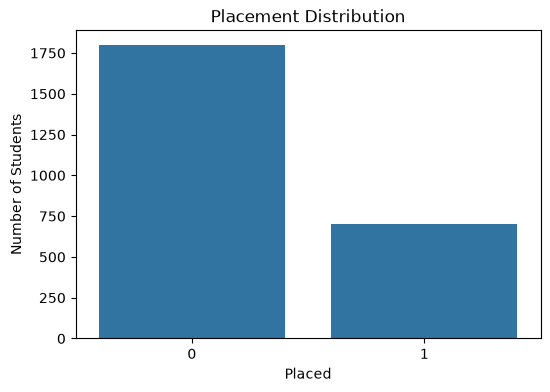

In [33]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="placed"
)

plt.title("Placement Distribution")
plt.xlabel("Placed")
plt.ylabel("Number of Students")

plt.show()

In [34]:
numerical_features = [
    "cgpa",
    "backlogs",
    "internship_months",
    "coding_score",
    "projects",
    "workshops"
]

display(
    df[numerical_features].describe().T
)

,count,mean,std,min,25%,50%,75%,max
cgpa,2382.0,7.274551,0.853967,5.0,6.7,7.29,7.8575,10.0
backlogs,2332.0,0.743997,0.871437,0.0,0.0,1.00,1.0000,6.0
internship_months,2500.0,1.975200,2.137197,0.0,0.0,1.00,4.0000,6.0
coding_score,1975.0,54.278177,16.306036,5.2,43.4,54.30,65.2000,100.0
projects,2500.0,1.510800,1.290019,0.0,1.0,1.00,2.0000,10.0
workshops,2500.0,2.085600,1.416713,0.0,1.0,2.00,3.0000,4.0


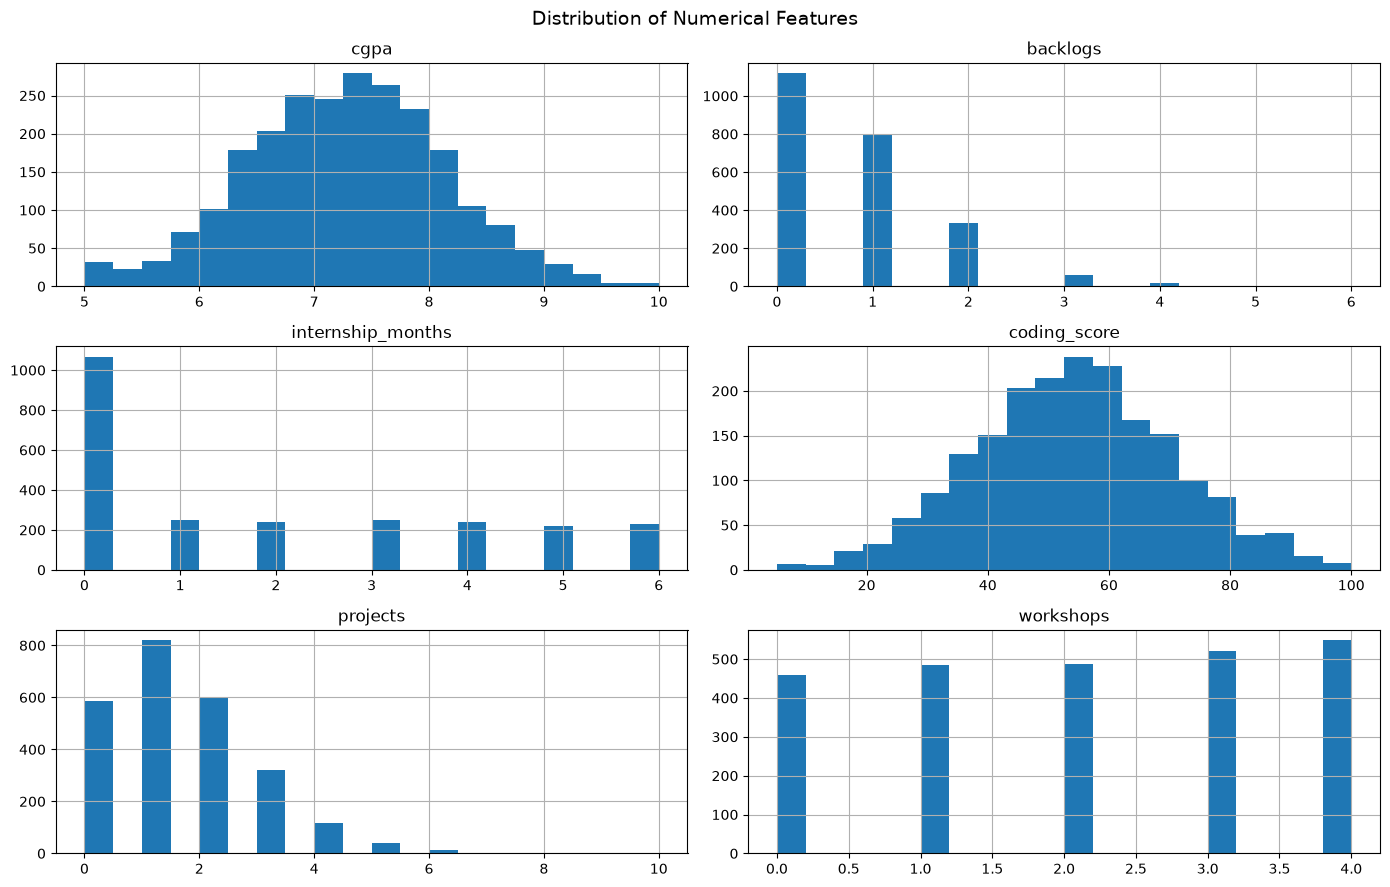

In [35]:
df[numerical_features].hist(
    figsize=(14, 9),
    bins=20
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Numerical features and placement

Next, I want to see whether placed and non-placed students have noticeably different feature distributions.

This is exploratory analysis only. A visible relationship does not mean that the feature directly causes placement.

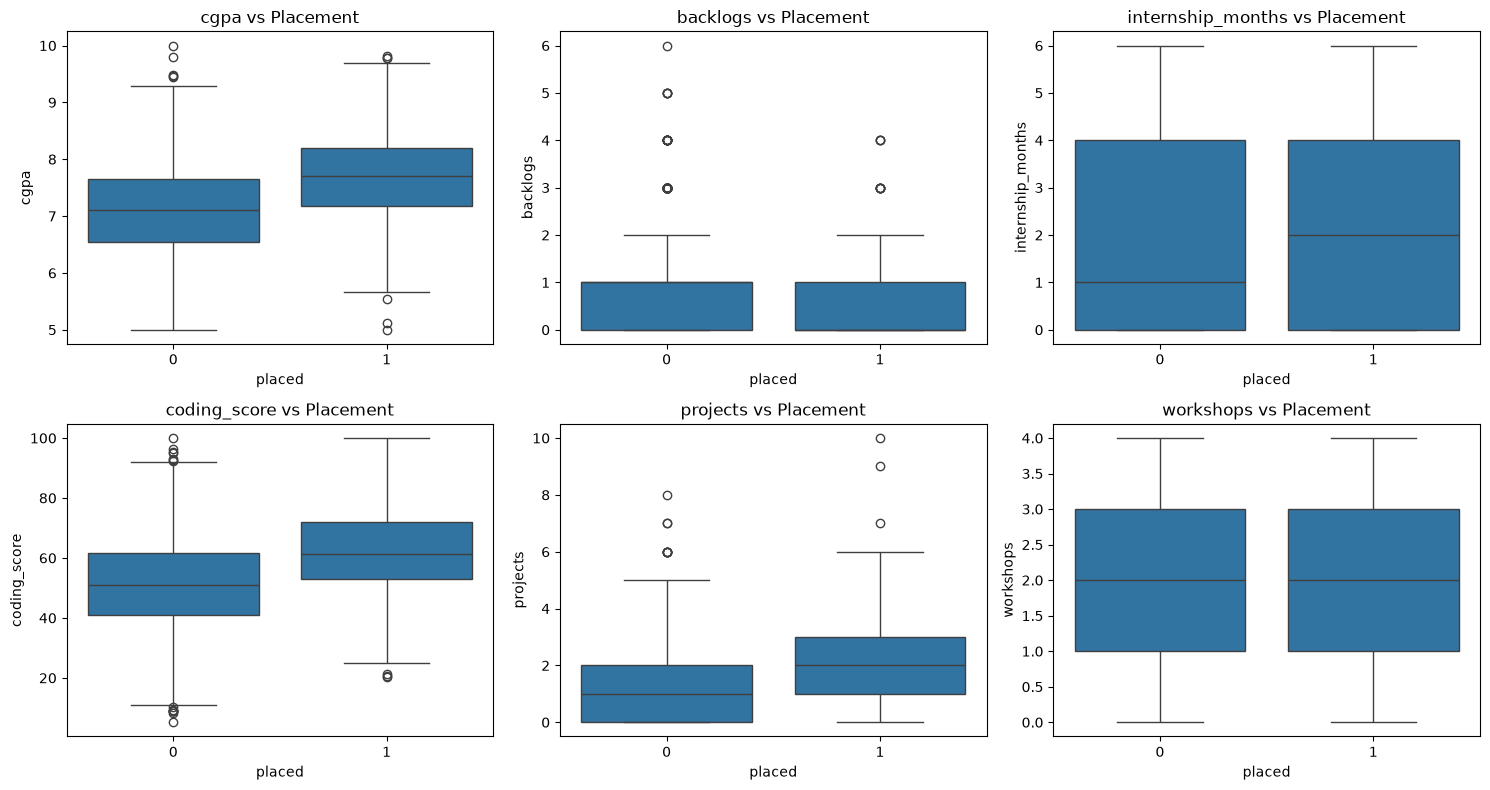

In [36]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)

for ax, feature in zip(
    axes.flatten(),
    numerical_features
):
    sns.boxplot(
        data=df,
        x="placed",
        y=feature,
        ax=ax
    )

    ax.set_title(
        f"{feature} vs Placement"
    )

plt.tight_layout()
plt.show()

## 8. Exploring categorical features

The dataset also contains categorical information such as department and city tier.

I will check how placement rates vary across these groups.

This helps us understand whether categorical information should be included in the model.

In [37]:
categorical_features = [
    "department",
    "city_tier"
]

for feature in categorical_features:
    print(f"\n{feature}")
    print(df[feature].value_counts())


department
department
CSE      1074
IT        535
ECE       273
EEE       269
MECH      209
CIVIL     140
Name: count, dtype: int64

city_tier
city_tier
2    1015
1     830
3     655
Name: count, dtype: int64


In [38]:
department_placement = pd.crosstab(
    df["department"],
    df["placed"],
    normalize="index"
) * 100

display(
    department_placement.round(2)
)

placed,0,1
department,,
CIVIL,86.43,13.57
CSE,61.64,38.36
ECE,81.32,18.68
EEE,79.18,20.82
IT,75.51,24.49
MECH,84.21,15.79


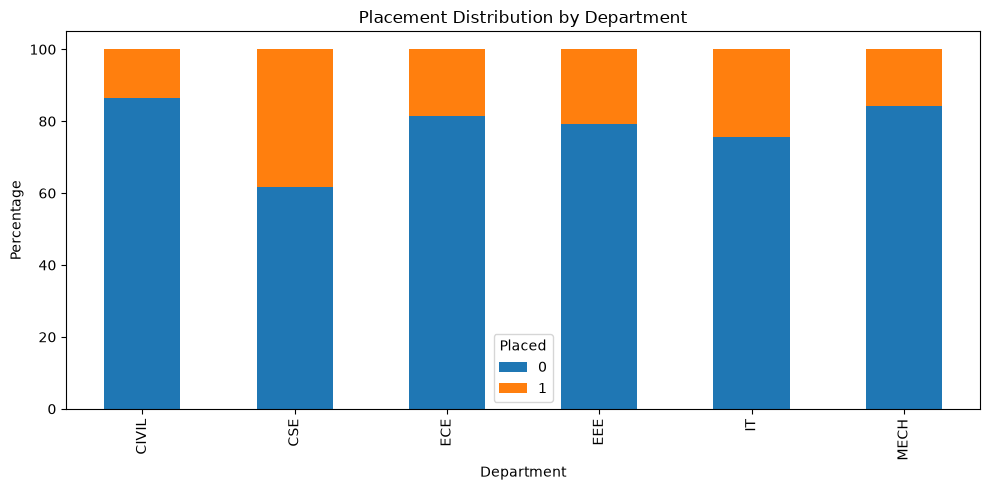

In [39]:
department_placement.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title(
    "Placement Distribution by Department"
)

plt.xlabel("Department")
plt.ylabel("Percentage")

plt.legend(
    title="Placed"
)

plt.tight_layout()
plt.show()

In [40]:
city_placement = pd.crosstab(
    df["city_tier"],
    df["placed"],
    normalize="index"
) * 100

display(
    city_placement.round(2)
)

placed,0,1
city_tier,,
1,72.29,27.71
2,73.00,27.00
3,69.77,30.23


## 9. Correlation between numerical variables

Correlation gives a quick view of linear relationships between numerical variables.

I will use it only as an exploratory tool. Tree-based models can learn nonlinear relationships, so low linear correlation does not automatically mean that a feature is useless.

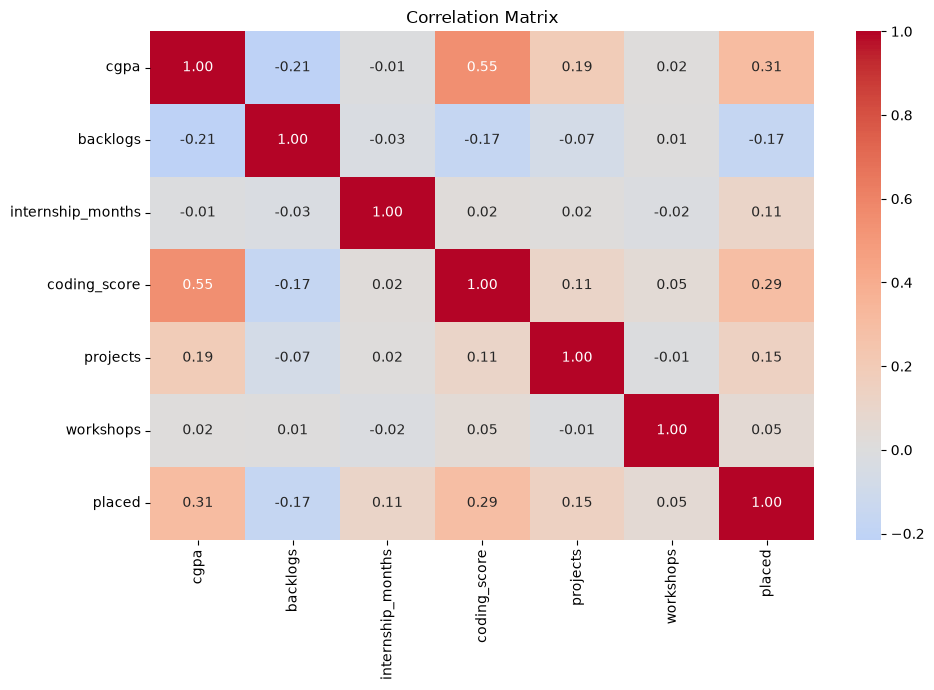

In [43]:
correlation_data = df[
    numerical_features + ["placed"]
]

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

## 10. Leakage audit

One of the most important parts of this analysis is checking whether any feature contains information that would not realistically be available when we are making the prediction.

The dataset contains a `status_code` field.

For this solution, I consider `status_code` to be target leakage because it can contain information associated with the placement outcome.

A model using this feature could obtain a high F1-score without actually learning the underlying student-placement relationship.

Therefore, I will completely exclude `status_code` from the model.

I will also exclude `student_id` because it is only an identifier and should not be used as a predictive feature.

This means the model will use only information that is appropriate for prediction.

In [44]:
LEAKAGE_COLUMNS = [
    "status_code"
]

ID_COLUMNS = [
    "student_id"
]

print("Excluded because of leakage:")
print(LEAKAGE_COLUMNS)

print("\nExcluded because they are identifiers:")
print(ID_COLUMNS)

Excluded because of leakage:
['status_code']

Excluded because they are identifiers:
['student_id']


## 11. Preparing the modeling data

Now I separate the target from the input features.

I remove:

- `placed` → target
- `student_id` → identifier
- `status_code` → leakage

No model in this notebook will receive `status_code`.

In [45]:
X = df.drop(
    columns=[
        "placed",
        "student_id",
        "status_code"
    ]
)

y = df["placed"]

print("Features used by the models:")

for column in X.columns:
    print(f"- {column}")

Features used by the models:
- department
- city_tier
- cgpa
- backlogs
- internship_months
- coding_score
- projects
- workshops


## 12. Creating a validation set

I will keep 20% of the data aside for validation.

Because the target is imbalanced, I use a stratified split. This keeps approximately the same proportion of placed and non-placed students in both sets.

The validation set will only be used for evaluating the trained models and tuning the final decision threshold.

In [46]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_valid))

print("\nTraining class distribution:")
print(
    y_train.value_counts(normalize=True)
)

print("\nValidation class distribution:")
print(
    y_valid.value_counts(normalize=True)
)

Training samples: 2000
Validation samples: 500

Training class distribution:
placed
0    0.719
1    0.281
Name: proportion, dtype: float64

Validation class distribution:
placed
0    0.72
1    0.28
Name: proportion, dtype: float64


## 13. Preprocessing

There are two types of input features.

Numerical features may contain missing values, so I will replace missing values with the median.

The department is categorical, so I will fill missing values with the most frequent category and then one-hot encode it.

I use a scikit-learn Pipeline so that exactly the same preprocessing is automatically applied during validation and later during prediction.

In [47]:
numerical_features = [
    "city_tier",
    "cgpa",
    "backlogs",
    "internship_months",
    "coding_score",
    "projects",
    "workshops"
]

categorical_features = [
    "department"
]

numeric_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numeric_preprocessor,
            numerical_features
        ),
        (
            "categorical",
            categorical_preprocessor,
            categorical_features
        )
    ]
)

In [50]:
X_train_processed = preprocessor.fit_transform(X_train)

print("Processed data shape:", X_train_processed.shape)
print("Contains NaN:", np.isnan(X_train_processed).any())

Processed data shape: (2000, 13)
Contains NaN: False


## 14. Models to compare

I will compare four different modeling approaches.

### Logistic Regression
This is my simple and interpretable baseline. It helps me understand how much performance can be achieved with a relatively simple linear model.

### Random Forest
Random Forest can capture nonlinear relationships and interactions between student features without requiring us to manually specify them.

### LightGBM
LightGBM is a gradient boosting model designed to work efficiently on tabular data. It is lightweight and generally fast to train.

### XGBoost
XGBoost is another strong gradient boosting method. Comparing it with LightGBM lets us see whether the additional boosting complexity actually improves F1 on this dataset.

I will not assume beforehand that one model is the winner. The validation results will decide.

In [52]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]
)

In [53]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=400,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

In [54]:
lightgbm_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LGBMClassifier(
                n_estimators=300,
                learning_rate=0.03,
                num_leaves=20,
                max_depth=5,
                subsample=0.8,
                colsample_bytree=0.8,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                verbosity=-1
            )
        )
    ]
)

In [55]:
xgboost_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.03,
                max_depth=4,
                min_child_weight=2,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

## 15. Training the models

I will now train all four models using exactly the same training data and preprocessing.

Keeping the preprocessing and validation setup consistent makes the comparison fair.

In [56]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "LightGBM": lightgbm_model,
    "XGBoost": xgboost_model
}

validation_results = []

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_valid
    )

    probabilities = model.predict_proba(
        X_valid
    )[:, 1]

    validation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_valid,
            predictions
        ),
        "Precision": precision_score(
            y_valid,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_valid,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_valid,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_valid,
            probabilities
        )
    })

results_df = pd.DataFrame(
    validation_results
).sort_values(
    "F1",
    ascending=False
)

display(
    results_df.round(4)
)

Training Logistic Regression...
Training Random Forest...
Training LightGBM...
Training XGBoost...


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.692,0.4660,0.6857,0.5549,0.7638
1,Random Forest,0.720,0.5000,0.5786,0.5364,0.7238
2,LightGBM,0.670,0.4359,0.6071,0.5075,0.7100
3,XGBoost,0.748,0.6061,0.2857,0.3883,0.7283


## 16. Comparing model performance

The main metric for this case study is F1-score for the positive class.

F1 balances precision and recall.

This is important because I don't want a model that predicts almost everyone as not placed just because the non-placed class is larger.

Accuracy, precision, recall, and ROC-AUC are still shown for additional context, but the final model selection will primarily consider F1.

## 17. Stratified 5-fold cross-validation

A single validation split can sometimes give an optimistic or pessimistic result depending on which students happen to be included.

To make the comparison more reliable, I will also use 5-fold stratified cross-validation.

Each fold keeps a similar proportion of placed and non-placed students.

The final comparison will consider the average F1 across all five folds rather than relying on one split.

In [100]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = []

for name, model in models.items():

    print(f"Evaluating {name}...")

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean F1": scores.mean(),
        "Std F1": scores.std(),
        "Fold 1": scores[0],
        "Fold 2": scores[1],
        "Fold 3": scores[2],
        "Fold 4": scores[3],
        "Fold 5": scores[4]
    })

cv_results_df = pd.DataFrame(
    cv_results
).sort_values(
    "Mean F1",
    ascending=False
)

display(
    cv_results_df.round(4)
)

Evaluating Logistic Regression...
Evaluating Random Forest...
Evaluating LightGBM...
Evaluating XGBoost...


,Model,Mean F1,Std F1,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
0,Logistic Regression,0.5609,0.0226,0.5852,0.5444,0.5632,0.5843,0.5273
2,LightGBM,0.5459,0.0182,0.5610,0.5104,0.5569,0.5513,0.5500
1,Random Forest,0.5438,0.0198,0.5686,0.5083,0.5502,0.5495,0.5424
3,XGBoost,0.4481,0.0237,0.4775,0.4240,0.4741,0.4424,0.4225


## 18. Selecting the candidate model

I will select the model based primarily on its mean cross-validated F1-score.

I will also look at the standard deviation across folds.

A model with a slightly higher average F1 but very unstable performance should be examined carefully.

The goal is not simply to choose the most complicated model. The goal is to find the model that provides strong and stable performance on unseen data.

In [101]:
best_model_name = cv_results_df.iloc[0]["Model"]

print(
    f"Best candidate based on mean CV F1: "
    f"{best_model_name}"
)

Best candidate based on mean CV F1: Logistic Regression


## 19. Optimizing the decision threshold

Most binary classifiers use 0.5 as the default probability threshold.

However, 0.5 is not necessarily the threshold that gives the best F1-score.

Because the case study evaluates positive-class F1, I will test different probability thresholds and select the threshold that gives the highest F1 on the validation predictions.

The threshold is tuned only after the model has been trained. It is not used to change the training labels.

In [102]:
best_model = models[best_model_name]

validation_probabilities = best_model.predict_proba(
    X_valid
)[:, 1]

thresholds = np.arange(
    0.10,
    0.91,
    0.01
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        validation_probabilities >= threshold
    ).astype(int)

    score = f1_score(
        y_valid,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "F1": score
    })

threshold_df = pd.DataFrame(
    threshold_results
)

best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold = float(
    best_threshold_row["Threshold"]
)

best_threshold_f1 = float(
    best_threshold_row["F1"]
)

print(
    f"Best threshold: {best_threshold:.2f}"
)

print(
    f"Validation F1 at best threshold: "
    f"{best_threshold_f1:.4f}"
)

Best threshold: 0.58
Validation F1 at best threshold: 0.5773


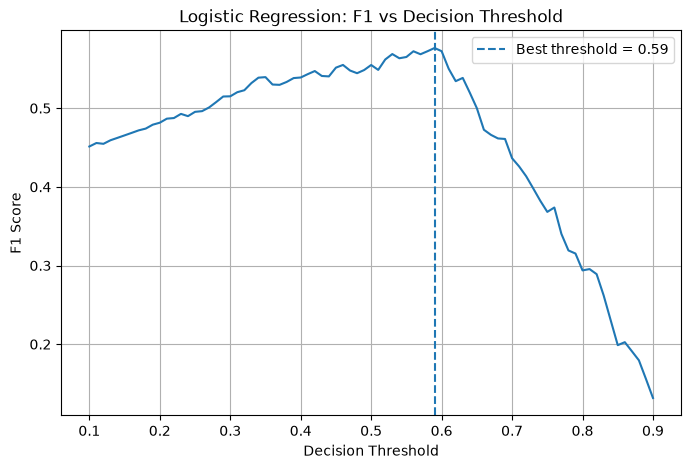

In [61]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"]
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.2f}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")

plt.title(
    f"{best_model_name}: F1 vs Decision Threshold"
)

plt.legend()
plt.grid(True)

plt.show()

### Default threshold vs tuned threshold

I will compare the standard 0.5 threshold with the optimized threshold.

This shows whether threshold tuning actually improves the metric that matters for this task.

In [103]:
default_predictions = (
    validation_probabilities >= 0.5
).astype(int)

tuned_predictions = (
    validation_probabilities >= best_threshold
).astype(int)

threshold_comparison = pd.DataFrame({
    "Threshold": [
        0.50,
        best_threshold
    ],
    "F1": [
        f1_score(
            y_valid,
            default_predictions
        ),
        f1_score(
            y_valid,
            tuned_predictions
        )
    ],
    "Precision": [
        precision_score(
            y_valid,
            default_predictions,
            zero_division=0
        ),
        precision_score(
            y_valid,
            tuned_predictions,
            zero_division=0
        )
    ],
    "Recall": [
        recall_score(
            y_valid,
            default_predictions,
            zero_division=0
        ),
        recall_score(
            y_valid,
            tuned_predictions,
            zero_division=0
        )
    ]
})

display(
    threshold_comparison.round(4)
)

,Threshold,F1,Precision,Recall
0,0.50,0.5584,0.4645,0.7
1,0.58,0.5773,0.5563,0.6


## 20. Final validation performance

After selecting the threshold, I will inspect the confusion matrix.

This helps me understand the types of mistakes the model is making:

- False Positive → predicted placed, but actually not placed
- False Negative → predicted not placed, but actually placed

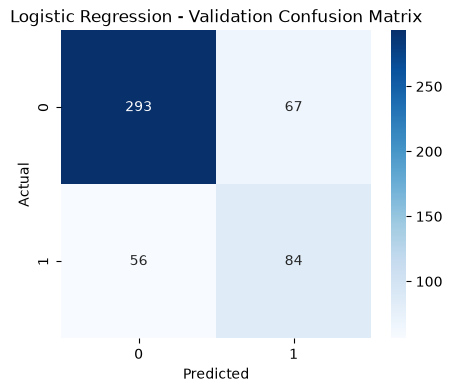

In [104]:
cm = confusion_matrix(
    y_valid,
    tuned_predictions
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    f"{best_model_name} - Validation Confusion Matrix"
)

plt.show()

In [105]:
print(
    classification_report(
        y_valid,
        tuned_predictions,
        target_names=[
            "Not Placed",
            "Placed"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Not Placed       0.84      0.81      0.83       360
      Placed       0.56      0.60      0.58       140

    accuracy                           0.75       500
   macro avg       0.70      0.71      0.70       500
weighted avg       0.76      0.75      0.76       500



## 21. Training the final model

After completing model comparison and threshold selection, I will train the selected model again using the complete training dataset.

This allows the final model to learn from all available labeled students.

The selected decision threshold will be saved separately and applied later by `predict.py`.

No model will be retrained during prediction.

In [106]:
final_model = models[best_model_name]

final_model.fit(
    X,
    y
)

print(
    f"Final {best_model_name} trained "
    f"on {len(X)} students."
)

Final Logistic Regression trained on 2500 students.


In [107]:
import os
import joblib

os.makedirs(
    "models",
    exist_ok=True
)

MODEL_PATH = "models/placement_model.joblib"

joblib.dump(
    final_model,
    MODEL_PATH
)

print(
    f"Model saved to: {MODEL_PATH}"
)

Model saved to: models/placement_model.joblib


In [108]:
import json

THRESHOLD_PATH = "models/threshold.json"

with open(
    THRESHOLD_PATH,
    "w"
) as file:

    json.dump(
        {
            "threshold": best_threshold
        },
        file,
        indent=4
    )

print(
    f"Threshold saved to: {THRESHOLD_PATH}"
)

Threshold saved to: models/threshold.json


### Saving model metadata

I will also save basic information about the final model.

This makes the training decision easier to reproduce later and clearly records which features were intentionally excluded.

In [109]:
metadata = {
    "model": best_model_name,
    "target": "placed",
    "excluded_columns": [
        "student_id",
        "status_code"
    ],
    "features_used": X.columns.tolist(),
    "threshold": best_threshold,
    "random_state": RANDOM_STATE
}

with open(
    "models/metadata.json",
    "w"
) as file:

    json.dump(
        metadata,
        file,
        indent=4
    )

print("Metadata saved successfully.")

Metadata saved successfully.


# Final Summary

The placement prediction problem was treated as a binary classification problem.

The main steps followed were:

1. I inspected the dataset and checked data quality.
2. I analyzed the target distribution and identified class imbalance.
3. I explored numerical and categorical features.
4. I performed a leakage audit.
5. I removed `student_id` because it is only an identifier.
6. I removed `status_code` because it contains target leakage.
7. I handled missing values through the preprocessing pipeline.
8. I compared Logistic Regression, Random Forest, LightGBM, and XGBoost.
9. I used stratified 5-fold cross-validation to compare model stability.
10. I selected the model based primarily on positive-class F1.
11. I optimized the probability threshold instead of assuming 0.5.
12. I retrained the selected model on the complete training data.
13. I saved the trained model, threshold, and metadata for inference.

The final prediction script will load these saved artifacts and will not retrain the model.